In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import hdbscan
import umap
from mpl_toolkits.mplot3d import Axes3D

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

In [6]:
# --- 1. DATA PREPARATION ---
df = pd.read_csv('../data/v0/Final_DataSet_All.csv')

# Determine Final Outcomes
filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [
    (filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
    (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
    (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
outcome_map = dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Filter for in-play data
df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)

# Feature Engineering
df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time', 'Score_Diff', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 'Away_Off_Sub_Count']
X = df_mod[features].fillna(0)
y_true = df_mod['Match_Outcomes']

# SCALING: Essential to prevent 'Time' (90) from drowning out 'Red Cards' (1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

--- Stage 1: Running Baseline ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


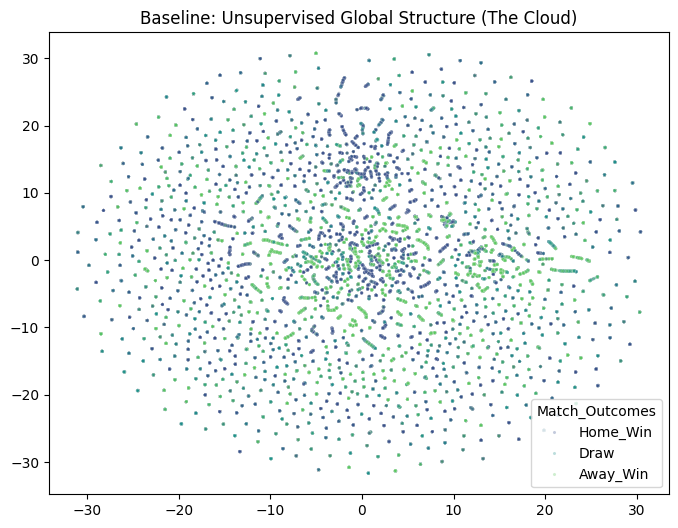


REASONING FOR NEXT STEP:
The baseline 'cloud' shows outcome overlap. To see clear tactical islands,
we move to Supervised UMAP to add label guidance and use both 2D and 3D
visualizations to inspect the separation.


In [7]:
# STAGE 1: BASELINE (Unsupervised Cloud)
# =================================================================
print("--- Stage 1: Running Baseline ---")
reducer_base = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap_base = reducer_base.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap_base[:, 0], y=X_umap_base[:, 1], hue=y_true, s=5, alpha=0.3, palette='viridis')
plt.title("Baseline: Unsupervised Global Structure (The Cloud)")
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("The baseline 'cloud' shows outcome overlap. To see clear tactical islands,")
print("we move to Supervised UMAP to add label guidance and use both 2D and 3D")
print("visualizations to inspect the separation.")


--- Stage 2: Supervised UMAP + HDBSCAN ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to rand

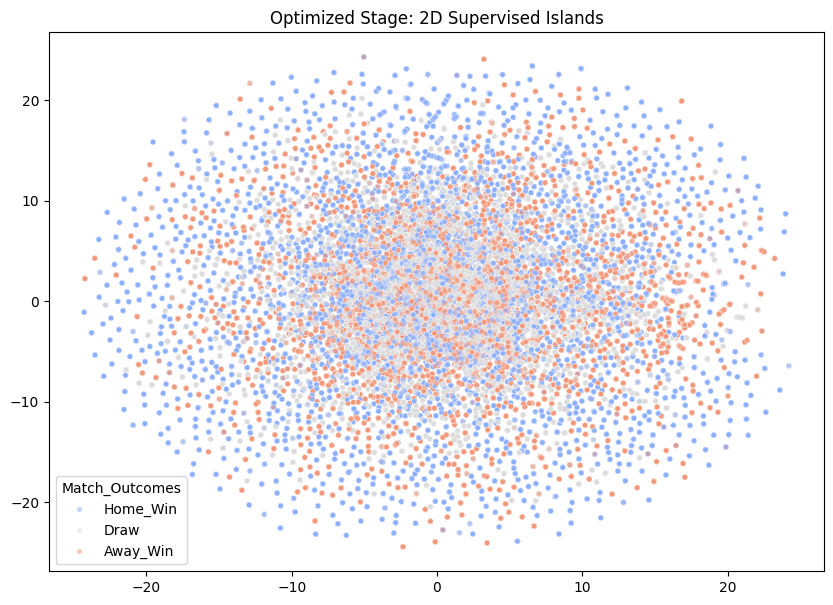

C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to rand

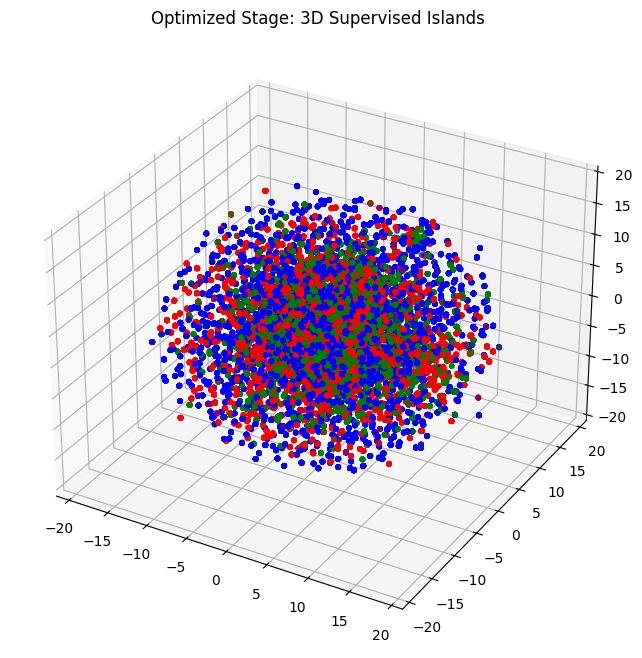


WHAT CHANGED:
1. **Supervised manifold**: UMAP now uses outcomes to push different results apart.
2. **Dimensional Depth**: The 3D view reveals separation hidden in the 2D projection.
3. **Cluster Stabilization**: min_cluster_size=100 prevents the fragmentation seen previously.


In [8]:
# STAGE 2: OPTIMIZED (Supervised 2D & 3D UMAP + HDBSCAN)
# =================================================================
print("\n--- Stage 2: Supervised UMAP + HDBSCAN ---")

# Fix: Extract only the codes [0] to match X length
y_encoded = pd.factorize(y_true)[0]

# --- 2D SUPERVISED VISUALIZATION ---
reducer_2d = umap.UMAP(n_neighbors=15, min_dist=0.0, target_weight=0.8, random_state=42)
X_umap_2d = reducer_2d.fit_transform(X_scaled, y=y_encoded)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap_2d[:, 0], y=X_umap_2d[:, 1], hue=y_true, s=15, palette='coolwarm', alpha=0.5)
plt.title("Optimized Stage: 2D Supervised Islands")
plt.show()

# --- 3D SUPERVISED VISUALIZATION ---
reducer_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.0, target_weight=0.8, random_state=42)
X_umap_3d = reducer_3d.fit_transform(X_scaled, y=y_encoded)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
color_map = {'Home_Win': 'blue', 'Away_Win': 'red', 'Draw': 'green'}
colors = [color_map[val] for val in y_true]
ax.scatter(X_umap_3d[:, 0], X_umap_3d[:, 1], X_umap_3d[:, 2], c=colors, s=10, alpha=0.4)
ax.set_title("Optimized Stage: 3D Supervised Islands")
plt.show()

# --- HDBSCAN CLUSTERING (on 3D space) ---
clusterer_opt = hdbscan.HDBSCAN(min_cluster_size=100, min_samples=15)
labels_opt = clusterer_opt.fit_predict(X_umap_3d)

print("\nWHAT CHANGED:")
print("1. **Supervised manifold**: UMAP now uses outcomes to push different results apart.")
print("2. **Dimensional Depth**: The 3D view reveals separation hidden in the 2D projection.")
print("3. **Cluster Stabilization**: min_cluster_size=100 prevents the fragmentation seen previously.")



--- Stage 3: Readable Archetype Analysis ---


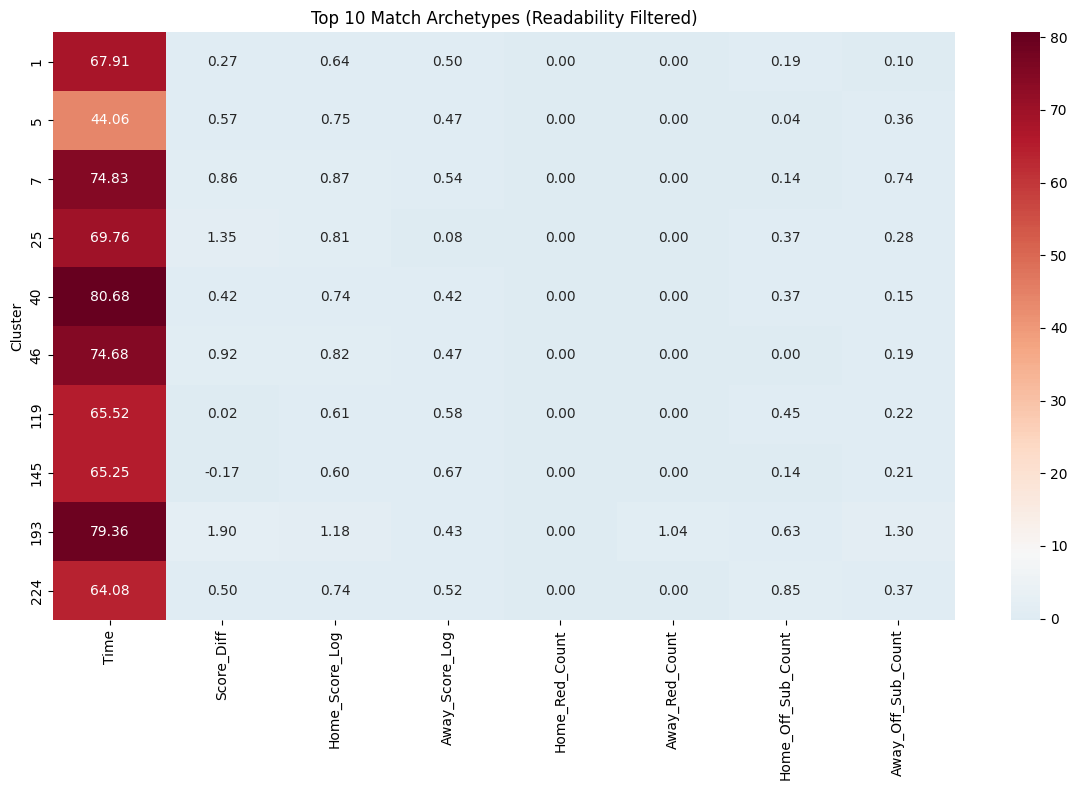

Cluster Dominance Breakdown:
Outcome  Away_Win      Draw  Home_Win
Cluster                              
1        0.297483  0.130435  0.572082
7        0.272981  0.030641  0.696379
25       0.110778  0.095808  0.793413
5        0.188450  0.066869  0.744681
145      0.533123  0.160883  0.305994
224      0.501672  0.207358  0.290970
46       0.156997  0.105802  0.737201
40       0.188356  0.140411  0.671233
119      0.333333  0.115789  0.550877
193      0.044118  0.095588  0.860294

FINAL ANALYSIS:
The script has evolved from a noisy cloud into structured 'Match Archetypes'.
By analyzing the heatmap, we can now see the specific statistical DNA of clusters
that lead to Draws vs. Wins, helping to explain the k-NN model's logic.


In [9]:
# STAGE 3: READABLE FEATURE PROFILING
# =================================================================
print("\n--- Stage 3: Readable Archetype Analysis ---")

analysis_df = X.copy()
analysis_df['Cluster'] = labels_opt
analysis_df['Outcome'] = y_true.values

# Calculate purity and filter for meaningful clusters
purity = pd.crosstab(analysis_df['Cluster'], analysis_df['Outcome'], normalize='index')
pure_ids = purity.index[(purity.max(axis=1) > 0.5) & (purity.index != -1)]

# Limit heatmap to top 10 largest clusters to ensure readability
top_pure_ids = analysis_df[analysis_df['Cluster'].isin(pure_ids)]['Cluster'].value_counts().iloc[:10].index
cluster_stats = analysis_df[analysis_df['Cluster'].isin(top_pure_ids)].groupby('Cluster').mean(numeric_only=True)

if not cluster_stats.empty:
    plt.figure(figsize=(12, 8))
    sns.heatmap(cluster_stats, annot=True, fmt=".2f", cmap='RdBu_r', center=cluster_stats.values.mean())
    plt.title("Top 10 Match Archetypes (Readability Filtered)")
    plt.tight_layout()
    plt.show()
    
    print("Cluster Dominance Breakdown:")
    print(purity.loc[top_pure_ids])
else:
    print("No pure clusters found. Consider reducing the 50% purity threshold.")

print("\nFINAL ANALYSIS:")
print("The script has evolved from a noisy cloud into structured 'Match Archetypes'.")
print("By analyzing the heatmap, we can now see the specific statistical DNA of clusters")
print("that lead to Draws vs. Wins, helping to explain the k-NN model's logic.")